# Simulations

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Code" else Path.cwd()

sys.path.append(str(PROJECT_ROOT / "Code"))
sys.path.append(str(PROJECT_ROOT / "Code" / "Data_Processing" / "Workfiles"))

import numpy as np
import pandas as pd
import networkx as nx
from sklearn.preprocessing import StandardScaler
from libpysal.weights import WSP
from spreg import ML_Lag
from esda.moran import Moran
from esda.moran import Moran_Local
import itertools

import time
from numpy.linalg import solve


from thesis_core import (
    simulate_unstructured_dirichlet,
    simulate_sar_ilr,
    simulate_sar_ilr_with_covariates,
    fit_sar_ilr,
    load_static_gtfs,
    canonical_stations,
    build_bus_station_edges,
    build_sar_weights
)

import preprocessing_busdata
from preprocessing_busdata import (
    aggregate_realtime_by_station,
    ilr_transform,
)

## Set up the Network

For simulations on the real network, the Berlin-Brandenburg bus network structure is set up.

In [2]:
# Load the static information of the bus network.
stops, trips, stop_times, routes = load_static_gtfs()
stops = canonical_stations(stops)

# Build the edges of the bus network.
edges_df = build_bus_station_edges(stops=stops, stop_times=stop_times, trips=trips, routes=routes)

# Extract the unique stations from the edges.
stations = pd.unique(edges_df[["from_station","to_station"]].astype(str).values.ravel()).tolist()

# Build the adjacency matrix  and the row-standardized spatial weights for the SAR model.
A, W_ps, keep_idx = build_sar_weights(edges_df, stations)
print("Stations:", len(stations))

Stations: 12616


## SAR Model with Unstructured Data on Real Adjacency

In a first simulation i.i.d. compositional data is generated on the Berlin-Brandeburg bus network, with and without spatial structure in the DGP. Without the spatial dependence the model should correctly produce a spatial correlation coefficient of 0.

In [3]:
# Simulate unstructured Dirichlet data with mean (0.1,0.8,0.1) and transform it to ILR coordinates.
Y = simulate_unstructured_dirichlet(A.shape[0])
Z = preprocessing_busdata.ilr_transform(Y)

# Fit the baseline SAR model without covariates.
models, _, _ = fit_sar_ilr(Z, W_ps, keep_idx)
print("rho estimates:", [m.rho for m in models])

rho estimates: [np.float64(-0.003161782252903032), np.float64(0.004273087297384162)]


## SAR Model with Structured Data on Real Adjacency

In contrast, we now simulate i.i.d compositional data that exhibits very strong spatial structure. Thus, we expect the spatial coefficient to capture some sort of spatial dependence. Smaller deviations from the true parameter value are expected due to finite-sample effects, stochastic noise, and the irregular structure of the real-world network.

In [4]:
# Do the exact same, but this time introduce structure into the data by 
# simulating it from a SAR process with a known rho.
rho_true = 0.75
Z = simulate_sar_ilr(W_ps.sparse, rho_true)
models, _, _ = fit_sar_ilr(Z, W_ps, keep_idx)

print("true rho:", rho_true)
print("estimated rho:", [m.rho for m in models])

true rho: 0.75
estimated rho: [np.float64(0.5491604566320175), np.float64(0.5491604566320175)]


## Synthetic Minimal Graph

In order to get a sensitivity analysis of the model's parameter recovery, smaller synthetic graphs are simulated with varying levels of spatial structure. The parameter is then estimated and compared to the underlying DGP.

### Monte Carlo on Rho Recovery

In [5]:
# Create a connected synthetic graph and convert into a 
# row-standardized spatial weights object for the SAR model.
def make_fixed_W(n=400, radius=0.15):
    rng = np.random.default_rng(36)
    # Create a random graph, with the radis controlling the sparsity of edges.
    G = nx.random_geometric_graph(n, radius=radius, seed=36)
    # Keep only the largest connected subgraph to eliminate isolates.
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    # Convert to adjacency matrix and then row-standardize.
    A = nx.to_scipy_sparse_array(G, format="csr")
    W_ps = WSP(A).to_W()
    W_ps.transform = "r"  # row-standardize
    return G, A, W_ps

# Define one replication od the MC experiment.
def one_replication(W_ps, A, rho_true, seed):
    """
    Returns dict with rhos (list), success flag, runtime, etc.
    """
    np.random.seed(seed)
    # Estimate the SAR-model after generating data with the specified rho.
    Z = simulate_sar_ilr(W_ps.sparse, rho=rho_true)
    models, _, _ = fit_sar_ilr(Z, W_ps, list(range(A.shape[0])))
    # Capture the rhos produced for each ilr-coordinate and calculate their mean.
    rhos = [float(m.rho) for m in models]
    out = {
        "rho_true": rho_true,
        "rho_hat_mean": float(np.mean(rhos)),
    }
    # Add the true rhos to the output.
    for j, r in enumerate(rhos):
        out[f"rho_hat_comp{j+1}"] = r
    return out

def run_mc_grid(rho_grid, n_grid, radius_grid, R=200, base_seed=36):
    # Set up the grid of scenarios and run the Monte Carlo simulations.
    results = []
    scenario_id = 0
    for n, radius in itertools.product(n_grid, radius_grid):
        # Yield the same row-standardized adjacency matrix for comparability.
        G, A, W_ps = make_fixed_W(n=n, radius=radius)
        for rho_true in rho_grid:
            # Perform R Monte Carlo runs.
            for r in range(R):
                # Set a new unique seed for each run
                seed = base_seed + scenario_id * 10000 + r
                # Perform a model fitting with the current rho as a DGP.
                # Add the current specifications to the output.
                out = one_replication(W_ps, A, rho_true, seed)
                out["n"] = n
                out["radius"] = radius
                out["scenario_id"] = scenario_id
                results.append(out)
        scenario_id += 1
    
    return pd.DataFrame(results)

In [6]:
# Set the different specifications that are to be tested in the Monte Carlo environment.
rho_grid     = [0.0, 0.3, 0.6, 0.9]     # weak -> strong dependence
n_grid       = [200, 400]              # small -> medium network
radius_grid  = [0.12, 0.18]            # sparse -> denser graph
R = 200                                  # Amount of times each specifications is run.
df_mc = run_mc_grid(rho_grid, n_grid, radius_grid, R=R)

In [7]:
def summarize_grid(df):
    # Group the different specifications from the MC experiment.
    grouped = df.groupby(["n", "radius", "rho_true"])

    # Calculate the mean and one standard deviation for each of the specifications.
    summary = grouped["rho_hat_mean"].agg(
        mean_hat = "mean",
        sd_hat   = "std"
    ).reset_index()

    return summary

summary_df = summarize_grid(df_mc)

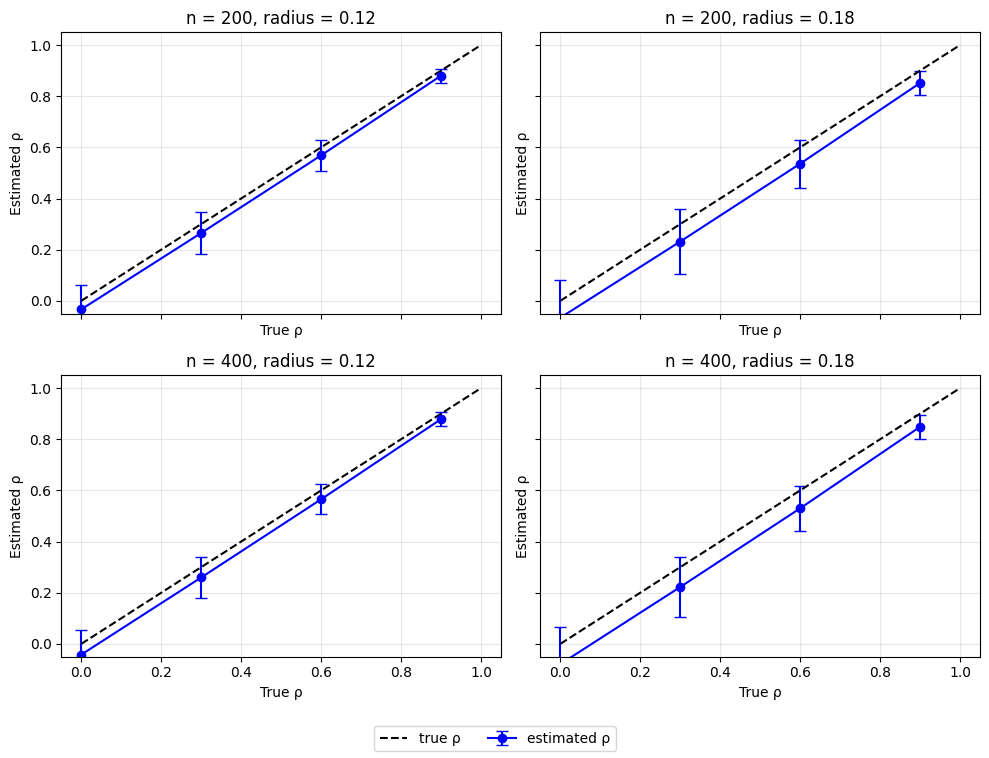

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, ((n, radius), sub) in zip(axes, summary_df.groupby(["n", "radius"])):

    # Estimated rho with arms of one uncertainty distance
    ax.errorbar(sub["rho_true"], sub["mean_hat"], yerr=sub["sd_hat"],
                marker="o", color="blue", capsize=4, label="estimated ρ")

    # True rho identity line
    ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="true ρ")

    # Build the plot, axes and grid.
    ax.set_title(f"n = {n}, radius = {radius}")
    ax.set_xlabel("True ρ")
    ax.set_ylabel("Estimated ρ")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

# Set a global legend.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## Centrality Inclusion on Synthetic Graph

In order to investigate how important it can be to include centrality measures in the model specifications, another MC simulation is set up to see what the recovery of the true underlying rho looks like and how much the residual Moran's I improves.

### Monte Carlo Recovery of Rho

In [9]:
# Set up a fixed graph for the MC experiment.
G, A, W_ps = make_fixed_W(n=400, radius=0.15)

# Calculate the centrality measures for each node.
deg = np.array([d for _, d in G.degree()])
eig = np.array(list(nx.eigenvector_centrality_numpy(G).values()))
pr  = np.array(list(nx.pagerank(G).values()))

# Scale the centrality measures and add them to a design matrix.
Xc = StandardScaler().fit_transform(np.column_stack([deg, eig, pr]))
X = np.column_stack([np.ones((len(G), 1)), Xc])

# Set the true underlying betas to simulate data and have the underlying DGP.
beta1 = np.array([0.0, 0.8, 0.0, 0.0])
beta2 = np.array([0.0, 0.0, -0.6, 0.0])

In [10]:
# Again, a single iteration of the model including centrality covariates is set up.
def one_replication_cov(W_ps, X, beta1, beta2, rho_true, seed):
    np.random.seed(seed)
    # Simulate the target data using the specified rho.
    Z = simulate_sar_ilr_with_covariates(W_ps.sparse, X, beta1, beta2, rho=rho_true, sigma=0.3, seed=seed)

    # Estimate the SAR-model without covariates on the synthetic graph.
    m1_noX = ML_Lag(Z[:, [0]], np.ones((Z.shape[0], 1)), w=W_ps)
    m2_noX = ML_Lag(Z[:, [1]], np.ones((Z.shape[0], 1)), w=W_ps)

    # Estimate the SAR-model with covariates on the synthetic graph.
    m1_X = ML_Lag(Z[:, [0]], X, w=W_ps)
    m2_X = ML_Lag(Z[:, [1]], X, w=W_ps)

    # Also calculate the residual Moran's I on the different specifications.
    moran1_noX = Moran(m1_noX.u.flatten(), W_ps)
    moran2_noX = Moran(m2_noX.u.flatten(), W_ps)
    moran1_X   = Moran(m1_X.u.flatten(), W_ps)
    moran2_X   = Moran(m2_X.u.flatten(), W_ps)

    # Capture the results of both the augmented and the simple spatial lag model.
    return {
        "True Rho": rho_true,
        "Rho1 Baseline": float(m1_noX.rho),
        "Rho2 Baseline": float(m2_noX.rho),
        "Rho1 Centrality": float(m1_X.rho),
        "Rho2 Centrality": float(m2_X.rho),
        "Moran1 Baseline": float(moran1_noX.I),
        "Moran2 Baseline": float(moran2_noX.I),
        "Moran1 Centrality": float(moran1_X.I),
        "Moran2 Centrality": float(moran2_X.I),
        "pMoran1 Baseline": float(moran1_noX.p_norm),
        "pMoran2 Baseline": float(moran2_noX.p_norm),
        "pMoran1 Centrality": float(moran1_X.p_norm),
        "pMoran2 Centrality": float(moran2_X.p_norm),
    }

In [11]:
# Perform a MC-Experiment along R=200 runs.
def mc_cov(W_ps, X, beta1, beta2, rho_true=0.5, R=200, base_seed=36):
    rows = [one_replication_cov(W_ps, X, beta1, beta2, rho_true, base_seed + r) for r in range(R)]
    return pd.DataFrame(rows)
df_cov = mc_cov(W_ps, X, beta1, beta2, rho_true=0.5, R=300)

### Visualisation of the MC experiment.

First, for the recovery of Rho.

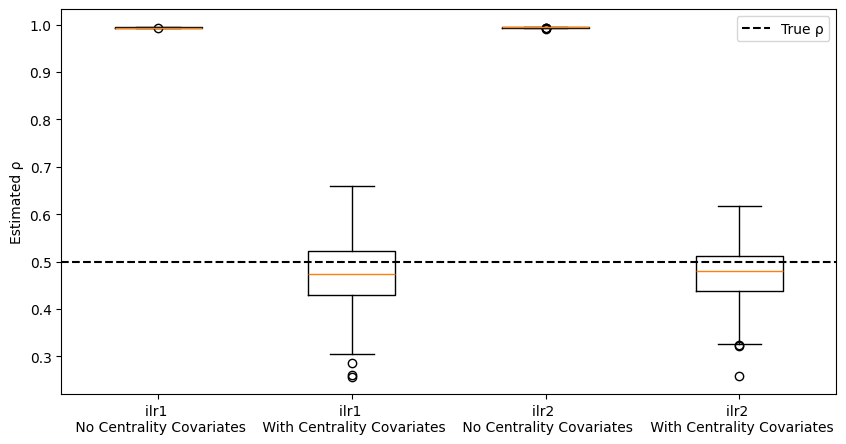

In [12]:
plt.figure(figsize=(10,5))
# Set up the boxplot for the estimations across the runs
plt.boxplot(
    [df_cov["Rho1 Baseline"], df_cov["Rho1 Centrality"], df_cov["Rho2 Baseline"], df_cov["Rho2 Centrality"]],
    labels=[
        "ilr1 \n No Centrality Covariates",
        "ilr1 \n With Centrality Covariates",
        "ilr2 \n No Centrality Covariates",
        "ilr2 \n With Centrality Covariates"  
    ])
# Add a visual line for the true underlying rho.
plt.axhline(0.5, linestyle="--", color="black", label="True ρ")
plt.ylabel("Estimated ρ")
plt.legend()
plt.show()

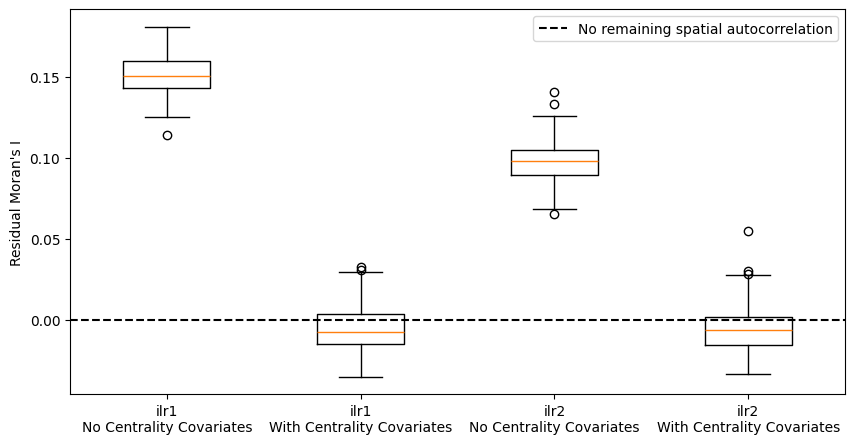

In [13]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    [df_cov["Moran1 Baseline"], df_cov["Moran1 Centrality"], df_cov["Moran2 Baseline"], df_cov["Moran2 Centrality"]],
    labels=[
        "ilr1\nNo Centrality Covariates",
        "ilr1\nWith Centrality Covariates",
        "ilr2\nNo Centrality Covariates",
        "ilr2\nWith Centrality Covariates"
    ]
)
plt.axhline(0, linestyle="--", color="black", label="No remaining spatial autocorrelation")
plt.ylabel("Residual Moran's I")
plt.legend()
plt.show()

# LISA Simulations

In the following section the model's ability to discover bottlenecks (signified by the LH-label) is investigated.

### MC Experiment of Bottleneck Identification.

In [14]:
# First create a helper to set up a graph
def make_small_graph(n=120, radius=0.23, seed=1):
    # Again, set up a minimal connected graph.
    G = nx.random_geometric_graph(n, radius=radius, seed=seed)
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    # Label nodes.
    G = nx.convert_node_labels_to_integers(G)
    # Set up the adjacency and row-standardized weight matrix.
    A = nx.to_scipy_sparse_array(G, format="csr")
    W = WSP(A).to_W()
    W.transform = "r"
    return G, W

# Next, compute the centrality from the new graph with this helper.
def compute_centrality(G):
    # Calculate the different centrality measures for the graph that has been set up.
    n = G.number_of_nodes()
    degree = np.array([d for _, d in G.degree()])
    eig = np.array(list(nx.eigenvector_centrality(G, max_iter=500).values()))
    # Approximate Betweenness
    k_sample = min(50, n-1)   # or None for exact (slower)
    bet = np.array(list(
        nx.betweenness_centrality(G, k=k_sample, seed=42).values()
    ))
    # Add to a design matrix.
    X = np.column_stack([bet, eig])
    X = StandardScaler().fit_transform(X)

    return X

# Define the ground truth of labels on the network.
def sample_random_painpoints(G, k=10, seed=1):
    # Set up a RNG and extract the size of the network.
    rng = np.random.default_rng(seed)
    nodes = np.array(list(G.nodes()))

    # Filter a random set of k nodes that are assigned pain-points.
    pain_nodes = rng.choice(nodes, size=k, replace=False)
    # Create a binary vector on the pain points.
    y_true = np.zeros(len(nodes), dtype=int)
    y_true[pain_nodes] = 1

    return y_true

# Introduce shocks to the ground truth of pain points in the network.
def simulate_sarx_LH(W, G, X, y_true, rho=0.6, beta=np.array([0.6, -0.5]), delta=2.0, sigma=0.4, seed=1):
    # Set up another RNG.
    rng = np.random.default_rng(seed)
    n = len(y_true)

    # Set up the effects centrality has on the network.
    mu = X @ beta
    # Create random noise for the network size.
    eps = rng.normal(0, sigma, size=n)

    # Using the ground truth vector, identify the nodes that are pain points.
    pain_idx = np.where(y_true == 1)[0]
    # Inject a negative shock to them.
    eps[pain_idx] -= delta

    # Collect the neighbors of each of the identified nodes and add a positive shock to them.
    neighbors = set()
    for i in pain_idx:
        neighbors |= set(G.neighbors(i))
    neighbors = np.array(list(neighbors - set(pain_idx)))
    if len(neighbors) > 0:
        eps[neighbors] += delta

    # Propagate the effects through the network with the predifned underlying DGP (I-rho*W)^(-1)(X*beta + epsilon).
    I = np.eye(n)
    A = I - rho * W.sparse.toarray()
    y = solve(A, mu + eps)
    return y

# Extract the LH-clusters on a given network after fitting either the baseline or the augmented model.
def detect_LH(y, W, X=None):
    n = len(y)
    # The choice of X allows to either fit the baseline or the centrality augmented model.
    if X is None:
        X_model = np.ones((n,1))
    else:
        X_model = np.column_stack([np.ones(n), X])
    # Fit the SAR model.
    m = ML_Lag(y.reshape(-1,1), X_model, w=W)
    # Extract the residuals produced in the fitting.
    u_hat = m.u.flatten()
    # Extract the LISA labels that correspond to LH-clusters.
    lisa = Moran_Local(u_hat, W)
    y_pred = ((lisa.q == 2) & (lisa.p_sim < 0.05)).astype(int)

    return y_pred

# A function producing evaluation metrics on the LH-predictions.
def compute_metrics(y_true, y_pred):
    # A number of different binary metrics are gathered.
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    # From these the recall and specificity can be calculated.
    # The Recall essentially produces the recovery rate on the ground truth.
    # The specificity measures the accuracy in actually identifying pain-points.
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    return recall, specificity


def run_simulation_with_centrality(R=100, n=120, k_pain=10, rho=0.6, delta=2.0, sigma=0.4, base_seed=123):
    rows = []
    # Perform R=100 MC loops
    for r in range(R):
        seed = base_seed + r
        # Create a new graph and row-standardized adjacency matrix
        G, W = make_small_graph(n=n, seed=seed)
        # Calculate the respective centrality measures
        X = compute_centrality(G)
        # Set up the ground truth of k pain-points.
        y_true = sample_random_painpoints(G, k=k_pain, seed=seed)
        # Introduce the shock to these k pain points and propagate the effects as well as noise through the system.
        y = simulate_sarx_LH(W=W, G=G, X=X, y_true=y_true, rho=rho, delta=delta, sigma=sigma, seed=seed)
        # Yield the LH-nodes after fitting the baseline model.
        pred_base = detect_LH(y, W, X=None)
        # Yield the LH-nodes after fitting the centrality augmented model.
        pred_cent = detect_LH(y, W, X=X)
        # Evaluate the Recall and Specificity of both specifications.
        rec_base, spec_base = compute_metrics(y_true, pred_base)
        rec_cent, spec_cent = compute_metrics(y_true, pred_cent)
        # Collect the results for the run in a results dictionary
        rows.append({
            "Recall Baseline": rec_base,
            "Specificity Baseline": spec_base,
            "Recall Centrality": rec_cent,
            "Specificity Centrality": spec_cent
        })
    # Create a results dataframe.
    df = pd.DataFrame(rows)
    # Evaluate the mean and standard deviation of the R runs.
    summary = df.agg(["mean","std"])

    return df, summary


In [15]:
def shock_level_study_centrality(deltas, R=100, n=120, k_pain=10, rho=0.6, sigma=0.4, base_seed=36):
    rows = []

    for d in deltas:
        # Perform the MC experiment at different shock levels delta.
        df_runs, _ = run_simulation_with_centrality(R=R, n=n, k_pain=k_pain, rho=rho,
                                                    delta=d,sigma=sigma,base_seed=base_seed)
        rows.append({
            "delta": d,
            # Recall Mean and Standard Deviation
            "recall_base_mean": df_runs["Recall Baseline"].mean(),
            "recall_base_sd": df_runs["Recall Baseline"].std(ddof=1),
            "recall_cent_mean": df_runs["Recall Centrality"].mean(),
            "recall_cent_sd": df_runs["Recall Centrality"].std(ddof=1),
            # Specificity Mean and Standard Deviation
            "specificity_base_mean": df_runs["Specificity Baseline"].mean(),
            "specificity_base_sd": df_runs["Specificity Baseline"].std(ddof=1),
            "specificity_cent_mean": df_runs["Specificity Centrality"].mean(),
            "specificity_cent_sd": df_runs["Specificity Centrality"].std(ddof=1),
        })

    return pd.DataFrame(rows)

# Define the grid of deltas that are to be investigated.
deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]

# Investigate the binary metrics across different delta levels.
df_shock_cent = shock_level_study_centrality(deltas=deltas, R=100, rho=0.6, sigma=0.4)

df_shock_cent

,delta,recall_base_mean,recall_base_sd,recall_cent_mean,recall_cent_sd,specificity_base_mean,specificity_base_sd,specificity_cent_mean,specificity_cent_sd
0,0.5,0.178,0.121921,0.196,0.106287,0.963636,0.018902,0.981091,0.014543
1,1.0,0.324,0.142219,0.321,0.118317,0.971818,0.016872,0.985182,0.012964
2,1.5,0.394,0.144124,0.380,0.123091,0.980182,0.014640,0.988000,0.012914
3,2.0,0.435,0.143108,0.407,0.118283,0.984909,0.013565,0.988909,0.013464
4,2.5,0.461,0.145571,0.421,0.125766,0.987455,0.013289,0.989182,0.013533
5,3.0,0.469,0.150886,0.432,0.130948,0.988091,0.013656,0.989273,0.012619
6,4.0,0.492,0.154841,0.431,0.133102,0.989000,0.012481,0.990000,0.012360


### Visualize Specificity and Recall

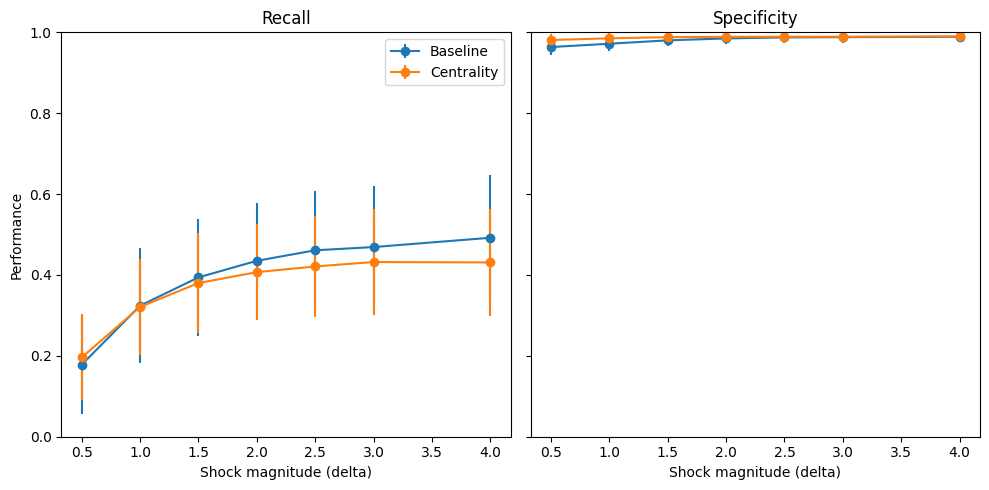

In [16]:
# Set up the subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# First plot the recall across different shock levels, with the error bars.
axes[0].errorbar(df_shock_cent["delta"], df_shock_cent["recall_base_mean"],
                 yerr=df_shock_cent["recall_base_sd"], fmt="o-", label="Baseline")

axes[0].errorbar(df_shock_cent["delta"], df_shock_cent["recall_cent_mean"],
                 yerr=df_shock_cent["recall_cent_sd"], fmt="o-", label="Centrality")

axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Shock magnitude (delta)")
axes[0].set_ylabel("Performance")
axes[0].set_title("Recall")
axes[0].legend()

# Plot the specificity analogously.
axes[1].errorbar(df_shock_cent["delta"], df_shock_cent["specificity_base_mean"],
                 yerr=df_shock_cent["specificity_base_sd"], fmt="o-")

axes[1].errorbar(df_shock_cent["delta"], df_shock_cent["specificity_cent_mean"],
                 yerr=df_shock_cent["specificity_cent_sd"], fmt="o-")

axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Shock magnitude (delta)")
axes[1].set_title("Specificity")

plt.tight_layout()
plt.show()

### Align the Empirical Bottleneck magnitude with the Simulations

To be able to decipher which Recall and Specificity can likely be assumed for the real network, look at the shock level that aligns with the empirical shock from the data in the "Models.ipynb" notebook under section "LISA analysis".

In [17]:
# The observed median magnitude from the empirical data is captured here.
target_median = 1.5757226801570854
# In order to see the standardized magnitude the pain points take at different shock levels
# a helper function is created that observed the magnitude for the pain-points in the system.
def simulated_dip_for_delta(delta, R=30, rho=0.6, sigma=1.0, base_seed=123):
    dips = []
    # Set up a MC experiment again.
    for r in range(R):
        seed = base_seed + r
        # Create a network with centralities, introduce pain points and fit the model like before.
        # Yield residuals and calculate the standardized deviation for all nodes 
        # in comparison to their neighbors.
        G, W = make_small_graph(n=120, seed=seed)
        X = compute_centrality(G)
        y_true = sample_random_painpoints(G, k=10, seed=seed)
        y = simulate_sarx_LH(W=W, G=G, X=X, y_true=y_true, rho=rho, delta=delta, sigma=sigma, seed=seed)
        X_model = np.column_stack([np.ones(len(y)), X])
        m = ML_Lag(y.reshape(-1,1), X_model, w=W)
        u = m.u.flatten()
        u_lag = W.sparse @ u
        dip = (u_lag - u) / u.std()

        # Extract the magnitudes for the pain-points only.
        dips.extend(dip[y_true == 1])

    return np.median(dips)


# Set up a grid of shocks to investigate
delta_grid = np.linspace(0.5, 4.0, 10)
calibration_results = []
# Perform the MC along the different shock levels
for d in delta_grid:
    med = simulated_dip_for_delta(d)
    calibration_results.append({
        "Delta": d,
        "Median Dip": med,
        # See how close the different shock levels come to the empirical magnitude.
        "Proximity to Empirical Magnitude": abs(med - target_median)
    })

df_calibration = pd.DataFrame(calibration_results)
# Sort by the Proximity.
df_calibration.sort_values("Proximity to Empirical Magnitude")

,Delta,Median Dip,Proximity to Empirical Magnitude
1,0.888889,1.503974,0.071749
2,1.277778,1.894253,0.318530
3,1.666667,2.147425,0.571703
0,0.500000,0.985485,0.590238
4,2.055556,2.348243,0.772520
5,2.444444,2.487471,0.911748
6,2.833333,2.586546,1.010823
7,3.222222,2.645398,1.069675
8,3.611111,2.703241,1.127518
9,4.000000,2.746563,1.170840


In [18]:
# Calculate Recall and Specificity for the calibrated shock level.
df_compare, summary_compare = run_simulation_with_centrality(
    R=100,
    delta=1.27,   # calibrated value
    rho=0.6,
    sigma=1.0
)

summary_compare

,Recall Baseline,Specificity Baseline,Recall Centrality,Specificity Centrality
mean,0.254000,0.969542,0.202000,0.978089
std,0.109563,0.013996,0.111898,0.014793


### Recall Heatmap along different Noise and Shock Levels Delta/Sigma for Both Models

In [19]:
def shock_noise_grid_centrality(deltas, sigmas, **kwargs):
    rows = []
    for d in deltas:
        for s in sigmas:
            # Run the MC with the given shock measures delta and sigma.
            df_runs, _ = run_simulation_with_centrality(delta=d, sigma=s,**kwargs)
            # Collect the results in an output table.
            rows.append({
                "delta": d,
                "sigma": s,
                "Recall Baseline": df_runs["Recall Baseline"].mean(),
                "Recall Centrality": df_runs["Recall Centrality"].mean()
            })

    # Collect the results and output the difference.
    df = pd.DataFrame(rows)
    df["delta_recall"] = df["Recall Centrality"] - df["Recall Baseline"]

    return df

In [20]:
# Set a grid of deltas and sigmas to be observed.
deltas = [1.0, 2.0, 3.0, 4.0]
sigmas = [0.2, 0.4, 0.6, 0.8]

# Run the MC experiment for each specification of delta and sigma.
df_grid_cent_clustered = shock_noise_grid_centrality(deltas, sigmas, R=100, n=120, k_pain=10,
                                                     rho=0.6, base_seed=123)



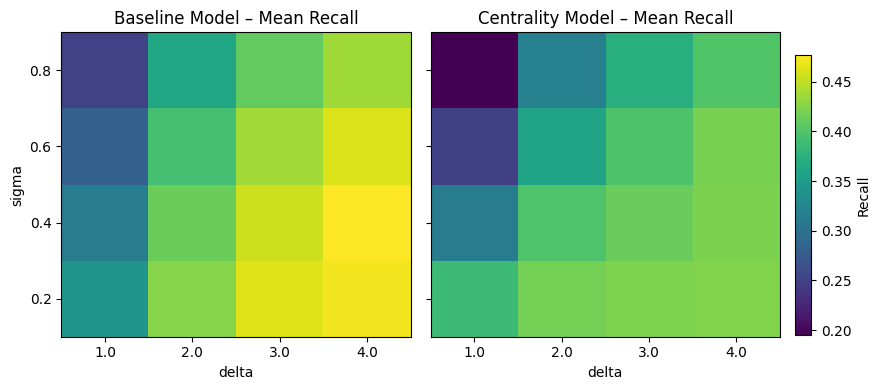

In [21]:
# For the colour range, extract the max and min recall values of both models.
all_values = np.concatenate([
    df_grid_cent_clustered["Recall Baseline"].values,
    df_grid_cent_clustered["Recall Centrality"].values,
])
vmin = all_values.min()
vmax = all_values.max()

# Set up two pivot tables for the respective values of sigma and delta.
pivot_base_clustered = df_grid_cent_clustered.pivot(index="sigma", columns="delta", values="Recall Baseline")
pivot_cent_clustered = df_grid_cent_clustered.pivot(index="sigma", columns="delta", values="Recall Centrality")

# Set up the subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
# First plot the recall for the baseline model.
im0 = axes[0].imshow(pivot_base_clustered.values, aspect="auto", origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_xticks(range(len(pivot_base_clustered.columns)))
axes[0].set_xticklabels(pivot_base_clustered.columns)
axes[0].set_yticks(range(len(pivot_base_clustered.index)))
axes[0].set_yticklabels(pivot_base_clustered.index)
axes[0].set_xlabel("delta")
axes[0].set_ylabel("sigma")
axes[0].set_title("Baseline Model – Mean Recall")

# Then plot the recall for the extended model.
im1 = axes[1].imshow(pivot_cent_clustered.values, aspect="auto", origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_xticks(range(len(pivot_cent_clustered.columns)))
axes[1].set_xticklabels(pivot_cent_clustered.columns)
axes[1].set_yticks(range(len(pivot_cent_clustered.index)))
axes[1].set_yticklabels(pivot_cent_clustered.index)
axes[1].set_xlabel("delta")
axes[1].set_title("Centrality Model – Mean Recall")

# Set up a shared colourbar and place it.
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label("Recall")

plt.tight_layout()
plt.show()